# SignalScope: Dataset Collection and EDA

This notebook builds a clean dataset for **SignalScope** using three public data sources:

1. **Yahoo Finance / yfinance** for stock prices, volume, returns, volatility, and drawdown.
2. **Google Trends / pytrends** for retail AI-attention signals.
3. **SEC EDGAR filings** for company-level AI adoption language signals.

Finnhub/news data has been removed. The notebook is designed to be non-breaking: malformed yfinance cache is redownloaded, Google Trends failures are skipped, and missing SEC folders do not crash the workflow.


## 0. Installation

Run once if packages are missing.

```bash
pip install pandas numpy matplotlib yfinance pytrends sec-edgar-downloader beautifulsoup4
```


In [1]:
from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 1. Configuration


In [2]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

YFINANCE_DIR = RAW_DIR / "yfinance"
TRENDS_DIR = RAW_DIR / "google_trends"

SEC_DIR = DATA_DIR / "sec"
SEC_FILINGS_DIR = SEC_DIR / "sec-edgar-filings"

for d in [DATA_DIR, RAW_DIR, PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR, YFINANCE_DIR, TRENDS_DIR, SEC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TICKERS = ["NVDA", "MSFT", "GOOG", "META", "AMZN", "AAPL"]
START_DATE = "2022-01-01"
END_DATE = "2025-01-01"
GEO = "US"

SEC_COMPANY_NAME = "SignalScope"
SEC_EMAIL = "rastogi.o@northeastern.edu"

AI_TREND_KEYWORDS = ["ChatGPT", "generative AI", "artificial intelligence", "AI stocks", "machine learning"]

SEC_AI_KEYWORDS = [
    "artificial intelligence", "generative ai", "machine learning", "large language model", "llm",
    "data center", "accelerated computing", "automation", "gpu", "cloud computing"
]

print("Project root:", PROJECT_ROOT)
print("Tickers:", TICKERS)
print("Date range:", START_DATE, "to", END_DATE)


Project root: e:\Om\signalscope
Tickers: ['NVDA', 'MSFT', 'GOOG', 'META', 'AMZN', 'AAPL']
Date range: 2022-01-01 to 2025-01-01


## 2. Utilities


In [3]:
def save_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


def read_csv_if_exists(path: Path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Could not read {path}: {e}")
        return None


def save_current_figure(name: str) -> None:
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")


## 3. Market Data from yfinance


In [4]:
try:
    import yfinance as yf
except ImportError as e:
    raise ImportError("Install yfinance using: pip install yfinance") from e


def normalize_yfinance_frame(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        flat_cols = []
        for col in df.columns:
            parts = [str(x) for x in col if str(x) not in ["", "None"]]
            flat_cols.append("_".join(parts))
        df.columns = flat_cols

    if not any(str(c).lower() in ["date", "datetime"] for c in df.columns):
        if isinstance(df.index, (pd.DatetimeIndex, pd.PeriodIndex)) or df.index.name is not None:
            df = df.reset_index()

    df.columns = [str(c).strip().lower().replace(" ", "_").replace(".", "_") for c in df.columns]

    ticker_suffix = f"_{ticker.lower()}"
    rename_map = {}
    for col in df.columns:
        base = col[:-len(ticker_suffix)] if col.endswith(ticker_suffix) else col
        rename_map[col] = base
    df = df.rename(columns=rename_map)

    for candidate in ["date", "datetime", "index", "level_0"]:
        if candidate in df.columns:
            df = df.rename(columns={candidate: "date"})
            break

    if "date" not in df.columns:
        return pd.DataFrame()

    if "adj_close" not in df.columns:
        for candidate in ["adjclose", "adjusted_close"]:
            if candidate in df.columns:
                df = df.rename(columns={candidate: "adj_close"})
                break

    required = ["date", "open", "high", "low", "close", "volume"]
    if not all(c in df.columns for c in required):
        return pd.DataFrame()

    keep = required + (["adj_close"] if "adj_close" in df.columns else [])
    df = df[keep].copy()

    if "adj_close" not in df.columns:
        df["adj_close"] = df["close"]

    df["ticker"] = ticker
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    for col in ["open", "high", "low", "close", "adj_close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["date", "open", "high", "low", "close", "volume"])
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    return df[["date", "ticker", "open", "high", "low", "close", "adj_close", "volume"]]


def add_market_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values(["ticker", "date"])
    g = df.groupby("ticker", group_keys=False)
    df["daily_return"] = g["close"].pct_change()
    df["log_return"] = np.log(df["close"] / g["close"].shift(1))
    df["return_5d_forward"] = g["close"].shift(-5) / df["close"] - 1
    df["return_10d_forward"] = g["close"].shift(-10) / df["close"] - 1
    df["rolling_volatility_20d"] = g["daily_return"].transform(lambda s: s.rolling(20, min_periods=10).std())
    df["volume_ma_20d"] = g["volume"].transform(lambda s: s.rolling(20, min_periods=10).mean())
    df["volume_std_20d"] = g["volume"].transform(lambda s: s.rolling(20, min_periods=10).std())
    df["volume_zscore"] = (df["volume"] - df["volume_ma_20d"]) / df["volume_std_20d"].replace(0, np.nan)
    df["low_5d_forward"] = g["low"].transform(lambda s: s.shift(-1).rolling(5, min_periods=1).min().shift(-4))
    df["drawdown_5d_forward"] = df["low_5d_forward"] / df["close"] - 1
    return df


def download_yfinance_data(tickers, start_date, end_date, force_download=False) -> pd.DataFrame:
    all_rows = []
    for ticker in tickers:
        out_path = YFINANCE_DIR / f"{ticker}.csv"
        used_cache = False

        if out_path.exists() and not force_download:
            cached = read_csv_if_exists(out_path)
            cached_norm = normalize_yfinance_frame(cached, ticker)
            if not cached_norm.empty:
                print(f"{ticker}: using cached yfinance data")
                all_rows.append(cached_norm)
                used_cache = True
            else:
                print(f"{ticker}: cache exists but is malformed. Redownloading.")

        if used_cache:
            continue

        print(f"{ticker}: downloading from yfinance")
        raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False, group_by="column")
        norm = normalize_yfinance_frame(raw, ticker)
        if norm.empty:
            print(f"Warning: no usable yfinance data for {ticker}")
            continue
        save_csv(norm, out_path)
        all_rows.append(norm)
        time.sleep(0.5)

    if not all_rows:
        raise ValueError("No market data loaded. Check internet connection, tickers, or date range.")

    market_df = pd.concat(all_rows, ignore_index=True)
    market_df = add_market_features(market_df)
    save_csv(market_df, PROCESSED_DIR / "market_features.csv")
    print("Market data shape:", market_df.shape)
    return market_df


market_df = download_yfinance_data(TICKERS, START_DATE, END_DATE, force_download=False)
market_df.head()


NVDA: using cached yfinance data
MSFT: using cached yfinance data
GOOG: using cached yfinance data
META: using cached yfinance data
AMZN: using cached yfinance data
AAPL: using cached yfinance data
Market data shape: (4518, 18)


,date,ticker,open,high,low,close,adj_close,volume,daily_return,log_return,return_5d_forward,return_10d_forward,rolling_volatility_20d,volume_ma_20d,volume_std_20d,volume_zscore,low_5d_forward,drawdown_5d_forward
3765,2022-01-03,AAPL,177.830002,182.880005,177.710007,182.009995,177.939728,104487900,NaN,NaN,-0.053953,-0.067084,NaN,NaN,NaN,NaN,168.169998,-0.076040
3766,2022-01-04,AAPL,182.630005,182.940002,179.119995,179.699997,175.681381,99310400,-0.012692,-0.012773,-0.025709,-0.074958,NaN,NaN,NaN,NaN,168.169998,-0.064162
3767,2022-01-05,AAPL,179.610001,180.169998,174.639999,174.919998,171.008301,94537600,-0.026600,-0.026960,0.003487,-0.059513,NaN,NaN,NaN,NaN,168.169998,-0.038589
3768,2022-01-06,AAPL,172.699997,175.300003,171.639999,172.000000,168.153580,96904000,-0.016693,-0.016834,0.001105,-0.055756,NaN,NaN,NaN,NaN,168.169998,-0.022267
3769,2022-01-07,AAPL,172.889999,174.139999,171.029999,172.169998,168.319794,86709100,0.000988,0.000988,0.005227,-0.061277,NaN,NaN,NaN,NaN,168.169998,-0.023233


## 4. Google Trends Data

Google Trends values are relative scores from 0 to 100, not absolute search counts. If Google blocks/rate-limits pytrends, this cell returns an empty dataframe and the notebook continues.


In [5]:
try:
    from pytrends.request import TrendReq
except ImportError:
    TrendReq = None


def download_google_trends(keywords, start_date, end_date, geo="US", force_download=False) -> pd.DataFrame:
    out_path = TRENDS_DIR / "google_trends_ai_keywords.csv"
    if out_path.exists() and not force_download:
        cached = read_csv_if_exists(out_path)
        if cached is not None and not cached.empty and "date" in cached.columns:
            print("Using cached Google Trends data")
            cached["date"] = pd.to_datetime(cached["date"], errors="coerce")
            return cached

    if TrendReq is None:
        print("pytrends is not installed. Run: pip install pytrends")
        return pd.DataFrame()

    if len(keywords) > 5:
        raise ValueError("Google Trends supports maximum 5 keywords per request.")

    try:
        timeframe = f"{start_date} {end_date}"
        pytrends = TrendReq(hl="en-US", tz=360, retries=2, backoff_factor=0.3)
        pytrends.build_payload(keywords, timeframe=timeframe, geo=geo)
        df = pytrends.interest_over_time().reset_index()
        if df.empty:
            print("Google Trends returned no data")
            return pd.DataFrame()
        if "isPartial" in df.columns:
            df = df.drop(columns=["isPartial"])
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        save_csv(df, out_path)
        print("Google Trends data shape:", df.shape)
        return df
    except Exception as e:
        print(f"Google Trends download failed. Continuing without Trends. Error: {e}")
        return pd.DataFrame()


def build_trends_features(trends_df: pd.DataFrame) -> pd.DataFrame:
    if trends_df is None or trends_df.empty:
        print("No Google Trends data available.")
        return pd.DataFrame(columns=["date", "ai_trend_score", "ai_trend_ma_4w", "ai_trend_spike", "ai_trend_bucket"])

    df = trends_df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    keyword_cols = [c for c in df.columns if c != "date"]
    for col in keyword_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["ai_trend_score"] = df[keyword_cols].mean(axis=1)
    df["ai_trend_ma_4w"] = df["ai_trend_score"].rolling(4, min_periods=1).mean()
    df["ai_trend_spike"] = df["ai_trend_score"] - df["ai_trend_ma_4w"]

    try:
        df["ai_trend_bucket"] = pd.qcut(df["ai_trend_score"], q=3, labels=["low", "medium", "high"], duplicates="drop").astype(str)
    except Exception:
        df["ai_trend_bucket"] = pd.cut(df["ai_trend_score"], bins=3, labels=["low", "medium", "high"], include_lowest=True).astype(str)

    out = df[["date", "ai_trend_score", "ai_trend_ma_4w", "ai_trend_spike", "ai_trend_bucket"] + keyword_cols]
    save_csv(out, PROCESSED_DIR / "google_trends_features.csv")
    return out


trends_raw_df = download_google_trends(AI_TREND_KEYWORDS, START_DATE, END_DATE, geo=GEO, force_download=False)
trends_features_df = build_trends_features(trends_raw_df)
trends_features_df.head()


Google Trends download failed. Continuing without Trends. Error: Retry.__init__() got an unexpected keyword argument 'method_whitelist'
No Google Trends data available.


,date,ai_trend_score,ai_trend_ma_4w,ai_trend_spike,ai_trend_bucket


## 5. SEC EDGAR Filings

This section downloads and parses SEC 10-K filings. If filings are missing, it returns an empty dataframe rather than crashing.


In [6]:
try:
    from sec_edgar_downloader import Downloader
except ImportError:
    Downloader = None

try:
    from bs4 import BeautifulSoup
except ImportError:
    BeautifulSoup = None


def download_sec_filings(tickers, form_type="10-K", after="2022-01-01", before="2025-01-01", force_download=False):
    if Downloader is None:
        print("sec-edgar-downloader is not installed. Run: pip install sec-edgar-downloader")
        return
    if not SEC_EMAIL or SEC_EMAIL == "your_email@example.com":
        print("SEC_EMAIL is not set. Skipping SEC download.")
        return

    dl = Downloader(company_name=SEC_COMPANY_NAME, email_address=SEC_EMAIL, download_folder=str(SEC_DIR))

    for ticker in tickers:
        ticker_dir = SEC_FILINGS_DIR / ticker / form_type
        existing = list(ticker_dir.glob("*/full-submission.txt")) if ticker_dir.exists() else []
        if existing and not force_download:
            print(f"{ticker}: already has {len(existing)} {form_type} filings. Skipping download.")
            continue
        print(f"{ticker}: downloading {form_type} filings")
        try:
            count = dl.get(form_type, ticker, after=after, before=before)
            print(f"{ticker}: downloaded/found {count} filings")
            time.sleep(1)
        except Exception as e:
            print(f"{ticker}: SEC download failed: {e}")


def extract_text_from_sec_submission(file_path: Path) -> str:
    raw = file_path.read_text(encoding="utf-8", errors="ignore")
    document_blocks = re.findall(r"<DOCUMENT>(.*?)</DOCUMENT>", raw, flags=re.DOTALL | re.IGNORECASE)
    selected_block = None
    for block in document_blocks:
        type_match = re.search(r"<TYPE>\s*([^\n\r<]+)", block, flags=re.IGNORECASE)
        if type_match and type_match.group(1).strip().upper().startswith("10-K"):
            selected_block = block
            break
    if selected_block is None:
        selected_block = raw
    text_match = re.search(r"<TEXT>(.*?)</TEXT>", selected_block, flags=re.DOTALL | re.IGNORECASE)
    html = text_match.group(1) if text_match else selected_block
    if BeautifulSoup is not None:
        soup = BeautifulSoup(html, "html.parser")
        for tag in soup(["script", "style"]):
            tag.decompose()
        text = soup.get_text(" ")
    else:
        text = re.sub(r"<[^>]+>", " ", html)
    text = re.sub(r"&nbsp;", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.lower().strip()


def extract_sec_dates(file_path: Path):
    raw_head = file_path.read_text(encoding="utf-8", errors="ignore")[:10000]
    filed_match = re.search(r"FILED AS OF DATE:\s*(\d{8})", raw_head)
    period_match = re.search(r"CONFORMED PERIOD OF REPORT:\s*(\d{8})", raw_head)
    filed_date = pd.to_datetime(filed_match.group(1), format="%Y%m%d", errors="coerce") if filed_match else pd.NaT
    period_of_report = pd.to_datetime(period_match.group(1), format="%Y%m%d", errors="coerce") if period_match else pd.NaT
    return filed_date, period_of_report


def count_keyword_occurrences(text: str, keyword: str) -> int:
    keyword = keyword.lower().strip()
    pattern = r"(?<![a-zA-Z])" + re.escape(keyword) + r"(?![a-zA-Z])"
    return len(re.findall(pattern, text, flags=re.IGNORECASE))


def safe_keyword_col(keyword: str) -> str:
    return keyword.lower().replace(" ", "_").replace("-", "_").replace("/", "_").replace(".", "")


def find_sec_filings_root() -> Path:
    candidates = [
        SEC_DIR / "sec-edgar-filings",
        RAW_DIR / "sec" / "sec-edgar-filings",
        DATA_DIR / "raw" / "sec" / "sec-edgar-filings",
        DATA_DIR / "sec" / "sec-edgar-filings",
    ]
    for pth in candidates:
        if pth.exists():
            return pth
    return SEC_DIR / "sec-edgar-filings"


def parse_sec_filings(tickers, form_type="10-K", keywords=None) -> pd.DataFrame:
    keywords = keywords or SEC_AI_KEYWORDS
    filings_root = find_sec_filings_root()
    rows = []
    print("Looking for SEC filings inside:", filings_root.resolve())

    for ticker in tickers:
        ticker_dir = filings_root / ticker / form_type
        if not ticker_dir.exists():
            print(f"{ticker}: no SEC directory found at {ticker_dir}")
            continue
        files = list(ticker_dir.glob("*/full-submission.txt"))
        if not files:
            print(f"{ticker}: no full-submission.txt files found")
            continue
        for file_path in files:
            try:
                text = extract_text_from_sec_submission(file_path)
                word_count = len(text.split())
                filed_date, period_of_report = extract_sec_dates(file_path)
                row = {
                    "ticker": ticker, "form_type": form_type, "accession": file_path.parent.name,
                    "filed_date": filed_date, "period_of_report": period_of_report,
                    "word_count": word_count, "file_path": str(file_path),
                }
                total = 0
                for kw in keywords:
                    col = safe_keyword_col(kw)
                    count = count_keyword_occurrences(text, kw)
                    row[f"{col}_count"] = count
                    row[f"{col}_density"] = count / max(word_count, 1)
                    total += count
                row["sec_ai_total_count"] = total
                row["sec_ai_density"] = total / max(word_count, 1)
                rows.append(row)
            except Exception as e:
                print(f"Failed to parse {file_path}: {e}")

    sec_df = pd.DataFrame(rows)
    if sec_df.empty:
        print("No SEC features created. Download filings first or continue without SEC features.")
        return sec_df
    sec_df = sec_df.sort_values(["ticker", "period_of_report", "filed_date"]).reset_index(drop=True)
    sec_df["sec_ai_density_yoy_change"] = sec_df.groupby("ticker")["sec_ai_density"].diff()
    sec_df["sec_ai_count_yoy_change"] = sec_df.groupby("ticker")["sec_ai_total_count"].diff()
    save_csv(sec_df, PROCESSED_DIR / "sec_filing_features.csv")
    print("SEC features shape:", sec_df.shape)
    return sec_df


# Set force_download=True only when you want to refresh SEC data.
download_sec_filings(TICKERS, form_type="10-K", after=START_DATE, before=END_DATE, force_download=False)
sec_features_df = parse_sec_filings(TICKERS, form_type="10-K", keywords=SEC_AI_KEYWORDS)
sec_features_df.head()


NVDA: already has 3 10-K filings. Skipping download.
MSFT: already has 3 10-K filings. Skipping download.
GOOG: already has 3 10-K filings. Skipping download.
META: already has 3 10-K filings. Skipping download.
AMZN: already has 3 10-K filings. Skipping download.
AAPL: already has 3 10-K filings. Skipping download.
Looking for SEC filings inside: E:\Om\signalscope\data\sec\sec-edgar-filings
SEC features shape: (18, 31)


,ticker,form_type,accession,filed_date,period_of_report,word_count,file_path,artificial_intelligence_count,artificial_intelligence_density,generative_ai_count,generative_ai_density,machine_learning_count,machine_learning_density,large_language_model_count,large_language_model_density,llm_count,llm_density,data_center_count,data_center_density,accelerated_computing_count,accelerated_computing_density,automation_count,automation_density,gpu_count,gpu_density,cloud_computing_count,cloud_computing_density,sec_ai_total_count,sec_ai_density,sec_ai_density_yoy_change,sec_ai_count_yoy_change
0,AAPL,10-K,0000320193-22-000108,2022-10-28,2022-09-24,33786,e:\Om\signalscope\data\sec\sec-edgar-filings\A...,0,0.000000,0,0.0,0,0.000000,0,0.0,0,0.0,3,0.000089,0,0.0,0,0.0,0,0.0,0,0.0,3,0.000089,NaN,NaN
1,AAPL,10-K,0000320193-23-000106,2023-11-03,2023-09-30,31484,e:\Om\signalscope\data\sec\sec-edgar-filings\A...,1,0.000032,0,0.0,1,0.000032,0,0.0,0,0.0,3,0.000095,0,0.0,0,0.0,0,0.0,0,0.0,5,0.000159,0.000070,2.0
2,AAPL,10-K,0000320193-24-000123,2024-11-01,2024-09-28,31879,e:\Om\signalscope\data\sec\sec-edgar-filings\A...,3,0.000094,0,0.0,2,0.000063,0,0.0,0,0.0,3,0.000094,0,0.0,0,0.0,0,0.0,0,0.0,8,0.000251,0.000092,3.0
3,AMZN,10-K,0001018724-22-000005,2022-02-04,2021-12-31,39817,e:\Om\signalscope\data\sec\sec-edgar-filings\A...,3,0.000075,0,0.0,4,0.000100,0,0.0,0,0.0,8,0.000201,0,0.0,0,0.0,0,0.0,0,0.0,15,0.000377,NaN,NaN
4,AMZN,10-K,0001018724-23-000004,2023-02-03,2022-12-31,42155,e:\Om\signalscope\data\sec\sec-edgar-filings\A...,3,0.000071,0,0.0,4,0.000095,0,0.0,0,0.0,9,0.000213,0,0.0,0,0.0,0,0.0,0,0.0,16,0.000380,0.000003,1.0


## 6. Merge All Features

Market data is daily. Google Trends is weekly. SEC filings are annual/event-style. The merge uses backward `merge_asof` so each trading day gets the most recent available signal.


In [7]:
def merge_all_features(market_df, trends_features_df=None, sec_features_df=None) -> pd.DataFrame:
    df = market_df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    if trends_features_df is not None and not trends_features_df.empty:
        trends = trends_features_df.copy()
        trends["date"] = pd.to_datetime(trends["date"], errors="coerce")
        trends = trends.dropna(subset=["date"]).sort_values("date")
        pieces = []
        for ticker, part in df.groupby("ticker", sort=False):
            merged = pd.merge_asof(part.sort_values("date"), trends.sort_values("date"), on="date", direction="backward")
            pieces.append(merged)
        df = pd.concat(pieces, ignore_index=True)
    else:
        df["ai_trend_score"] = np.nan
        df["ai_trend_ma_4w"] = np.nan
        df["ai_trend_spike"] = np.nan
        df["ai_trend_bucket"] = "missing"

    if sec_features_df is not None and not sec_features_df.empty and "filed_date" in sec_features_df.columns:
        sec = sec_features_df.copy()
        sec["filed_date"] = pd.to_datetime(sec["filed_date"], errors="coerce")
        sec = sec.dropna(subset=["filed_date"])
        keep_cols = ["ticker", "filed_date", "period_of_report", "sec_ai_total_count", "sec_ai_density", "sec_ai_density_yoy_change", "sec_ai_count_yoy_change"]
        keep_cols = [c for c in keep_cols if c in sec.columns]
        sec = sec[keep_cols].sort_values(["ticker", "filed_date"])
        pieces = []
        for ticker, part in df.groupby("ticker", sort=False):
            sec_part = sec[sec["ticker"] == ticker].sort_values("filed_date")
            if sec_part.empty:
                temp = part.copy()
                for c in ["period_of_report", "sec_ai_total_count", "sec_ai_density", "sec_ai_density_yoy_change", "sec_ai_count_yoy_change"]:
                    if c not in temp.columns:
                        temp[c] = np.nan
                pieces.append(temp)
            else:
                merged = pd.merge_asof(
                    part.sort_values("date"),
                    sec_part.drop(columns=["ticker"]).sort_values("filed_date"),
                    left_on="date", right_on="filed_date", direction="backward",
                )
                pieces.append(merged)
        df = pd.concat(pieces, ignore_index=True)
    else:
        df["sec_ai_total_count"] = np.nan
        df["sec_ai_density"] = np.nan
        df["sec_ai_density_yoy_change"] = np.nan
        df["sec_ai_count_yoy_change"] = np.nan

    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    save_csv(df, PROCESSED_DIR / "signalscope_master_dataset.csv")
    print("Master dataset shape:", df.shape)
    return df


master_df = merge_all_features(market_df, trends_features_df, sec_features_df)
master_df.head()


Master dataset shape: (4518, 28)


,date,ticker,open,high,low,close,adj_close,volume,daily_return,log_return,return_5d_forward,return_10d_forward,rolling_volatility_20d,volume_ma_20d,volume_std_20d,volume_zscore,low_5d_forward,drawdown_5d_forward,ai_trend_score,ai_trend_ma_4w,ai_trend_spike,ai_trend_bucket,filed_date,period_of_report,sec_ai_total_count,sec_ai_density,sec_ai_density_yoy_change,sec_ai_count_yoy_change
0,2022-01-03,AAPL,177.830002,182.880005,177.710007,182.009995,177.939728,104487900,NaN,NaN,-0.053953,-0.067084,NaN,NaN,NaN,NaN,168.169998,-0.076040,NaN,NaN,NaN,missing,NaT,NaT,NaN,NaN,NaN,NaN
1,2022-01-04,AAPL,182.630005,182.940002,179.119995,179.699997,175.681381,99310400,-0.012692,-0.012773,-0.025709,-0.074958,NaN,NaN,NaN,NaN,168.169998,-0.064162,NaN,NaN,NaN,missing,NaT,NaT,NaN,NaN,NaN,NaN
2,2022-01-05,AAPL,179.610001,180.169998,174.639999,174.919998,171.008301,94537600,-0.026600,-0.026960,0.003487,-0.059513,NaN,NaN,NaN,NaN,168.169998,-0.038589,NaN,NaN,NaN,missing,NaT,NaT,NaN,NaN,NaN,NaN
3,2022-01-06,AAPL,172.699997,175.300003,171.639999,172.000000,168.153580,96904000,-0.016693,-0.016834,0.001105,-0.055756,NaN,NaN,NaN,NaN,168.169998,-0.022267,NaN,NaN,NaN,missing,NaT,NaT,NaN,NaN,NaN,NaN
4,2022-01-07,AAPL,172.889999,174.139999,171.029999,172.169998,168.319794,86709100,0.000988,0.000988,0.005227,-0.061277,NaN,NaN,NaN,NaN,168.169998,-0.023233,NaN,NaN,NaN,missing,NaT,NaT,NaN,NaN,NaN,NaN


## 7. Dataset Quality Checks


In [8]:
print("Rows:", len(master_df))
print("Tickers:", master_df["ticker"].nunique())
print("Date range:", master_df["date"].min(), "to", master_df["date"].max())

missing_summary = master_df.isna().mean().sort_values(ascending=False).reset_index()
missing_summary.columns = ["column", "missing_ratio"]
missing_summary.head(25)


Rows: 4518
Tickers: 6
Date range: 2022-01-03 00:00:00 to 2024-12-31 00:00:00


,column,missing_ratio
0,ai_trend_ma_4w,1.000000
1,ai_trend_spike,1.000000
2,ai_trend_score,1.000000
3,sec_ai_count_yoy_change,0.433599
4,sec_ai_density_yoy_change,0.433599
5,sec_ai_density,0.103364
6,filed_date,0.103364
7,period_of_report,0.103364
8,sec_ai_total_count,0.103364
9,return_10d_forward,0.013280


In [9]:
master_df.groupby("ticker").agg(
    rows=("date", "count"),
    start_date=("date", "min"),
    end_date=("date", "max"),
    avg_daily_return=("daily_return", "mean"),
    avg_20d_volatility=("rolling_volatility_20d", "mean"),
    avg_volume_zscore=("volume_zscore", "mean"),
    avg_5d_forward_return=("return_5d_forward", "mean"),
    worst_5d_drawdown=("drawdown_5d_forward", "min"),
).reset_index()


,ticker,rows,start_date,end_date,avg_daily_return,avg_20d_volatility,avg_volume_zscore,avg_5d_forward_return,worst_5d_drawdown
0,AAPL,753,2022-01-03,2024-12-31,0.000569,0.016125,0.002629,0.003162,-0.137152
1,AMZN,753,2022-01-03,2024-12-31,0.000627,0.022762,0.012580,0.003497,-0.204479
2,GOOG,753,2022-01-03,2024-12-31,0.000575,0.019884,0.027285,0.003156,-0.142447
3,META,753,2022-01-03,2024-12-31,0.001207,0.027485,0.003845,0.006242,-0.330805
4,MSFT,753,2022-01-03,2024-12-31,0.000457,0.016689,0.001534,0.002586,-0.113725
5,NVDA,753,2022-01-03,2024-12-31,0.002586,0.033276,-0.046151,0.013407,-0.259197


## 8. EDA: Market Behavior


Saved figure: e:\Om\signalscope\reports\figures\NVDA_close_price.png


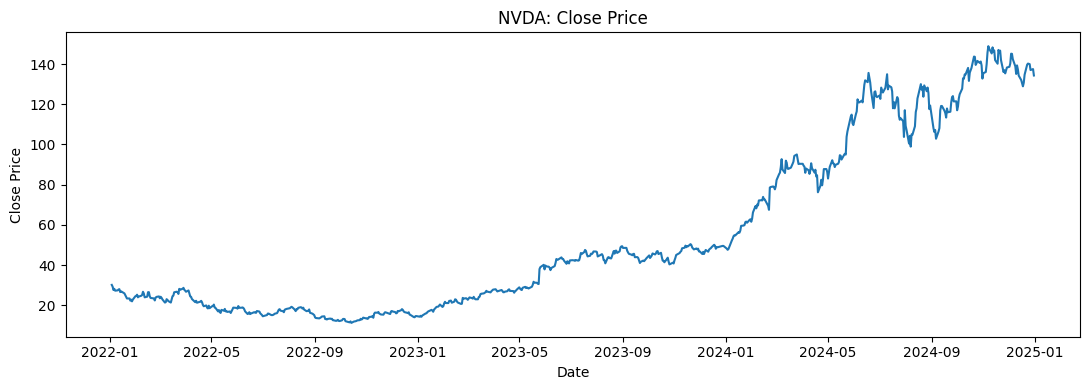

Saved figure: e:\Om\signalscope\reports\figures\MSFT_close_price.png


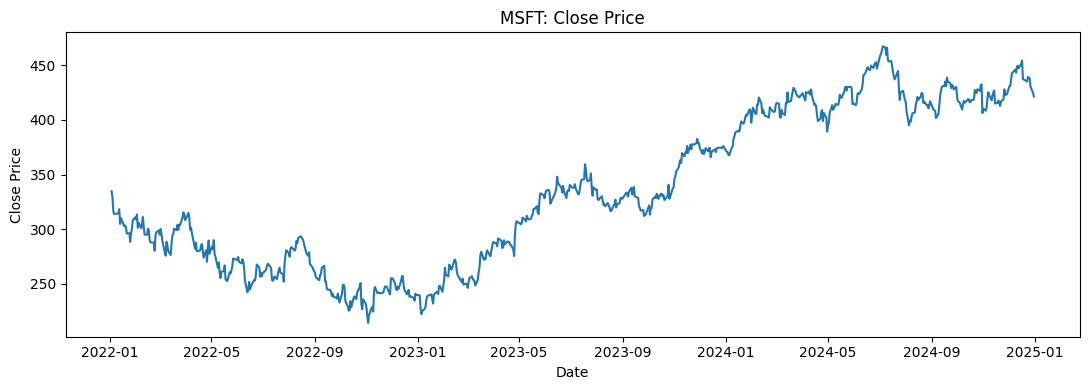

Saved figure: e:\Om\signalscope\reports\figures\GOOG_close_price.png


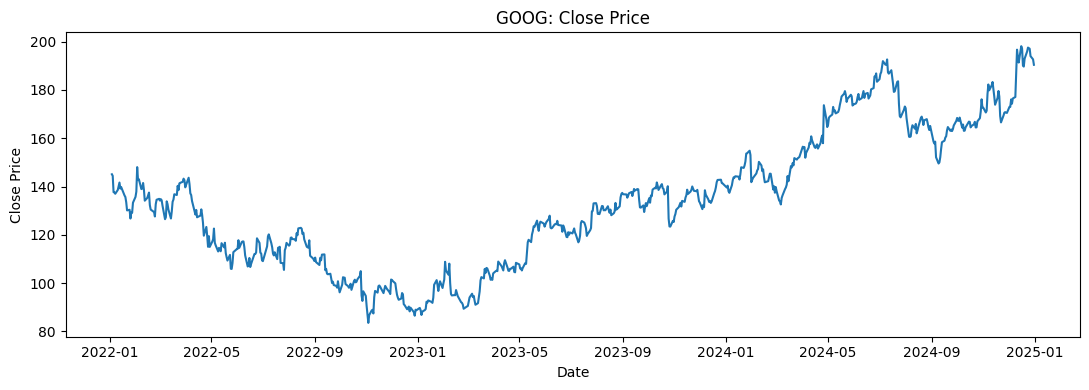

Saved figure: e:\Om\signalscope\reports\figures\META_close_price.png


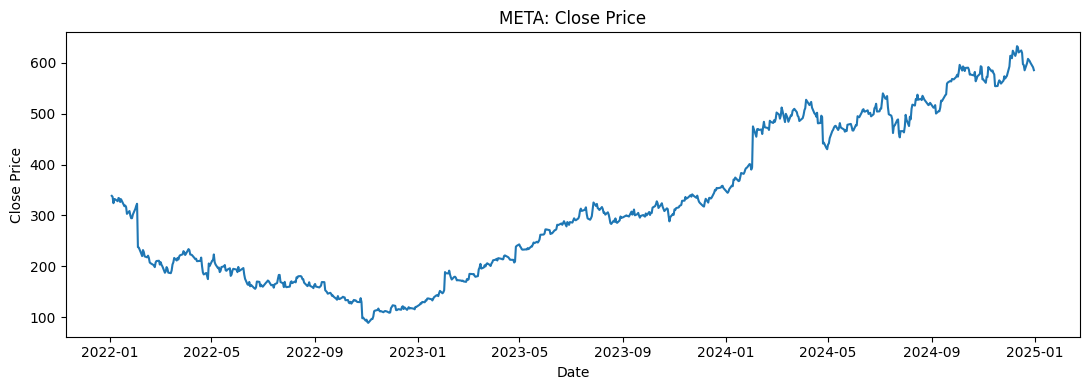

Saved figure: e:\Om\signalscope\reports\figures\AMZN_close_price.png


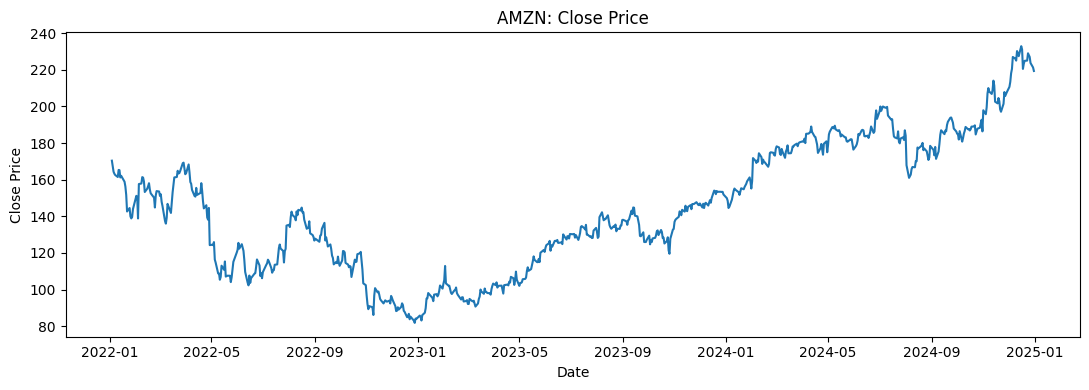

Saved figure: e:\Om\signalscope\reports\figures\AAPL_close_price.png


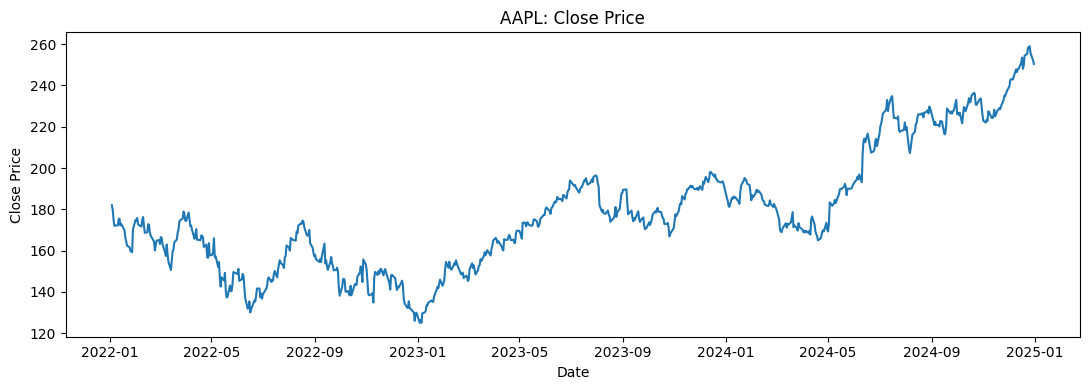

In [10]:
for ticker in TICKERS:
    part = master_df[master_df["ticker"] == ticker]
    if part.empty:
        continue
    plt.figure(figsize=(11, 4))
    plt.plot(part["date"], part["close"])
    plt.title(f"{ticker}: Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    save_current_figure(f"{ticker}_close_price.png")
    plt.show()


Saved figure: e:\Om\signalscope\reports\figures\NVDA_volume_zscore.png


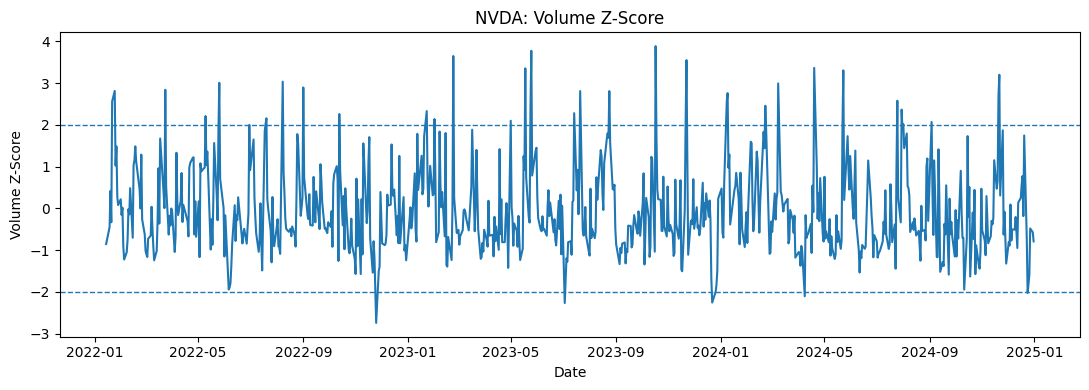

Saved figure: e:\Om\signalscope\reports\figures\MSFT_volume_zscore.png


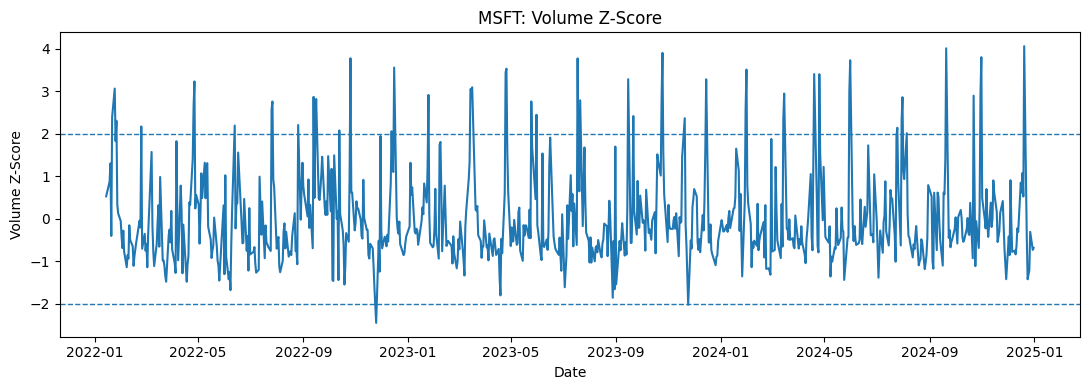

Saved figure: e:\Om\signalscope\reports\figures\GOOG_volume_zscore.png


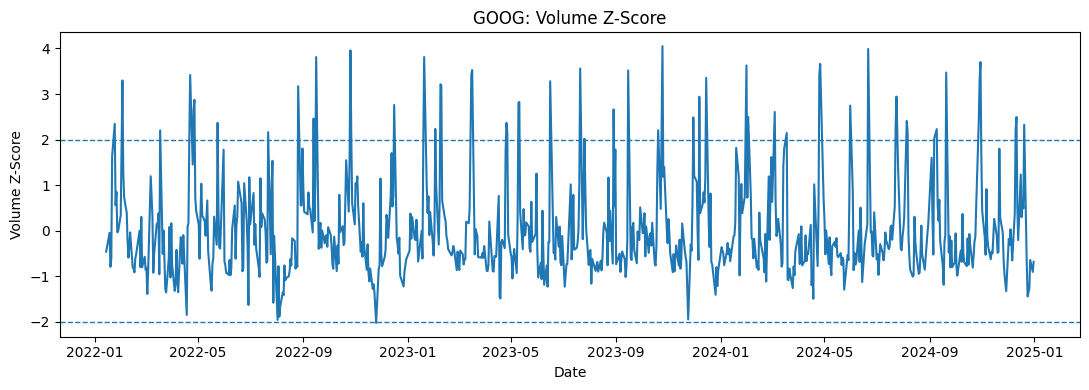

Saved figure: e:\Om\signalscope\reports\figures\META_volume_zscore.png


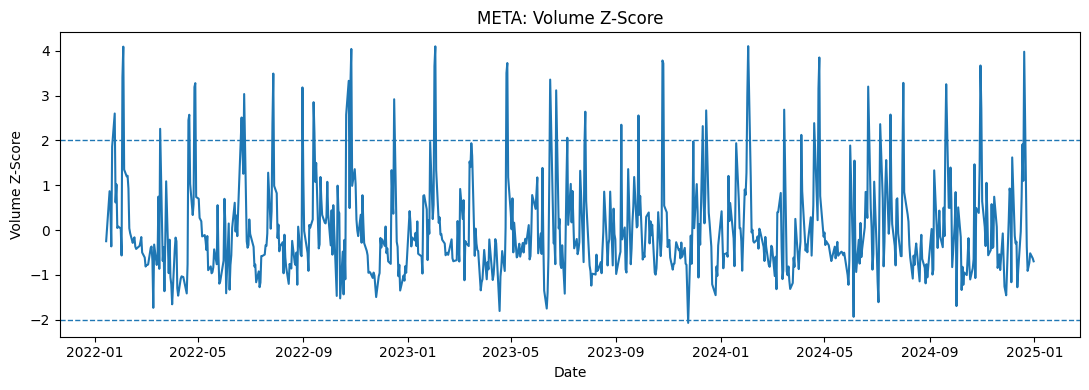

Saved figure: e:\Om\signalscope\reports\figures\AMZN_volume_zscore.png


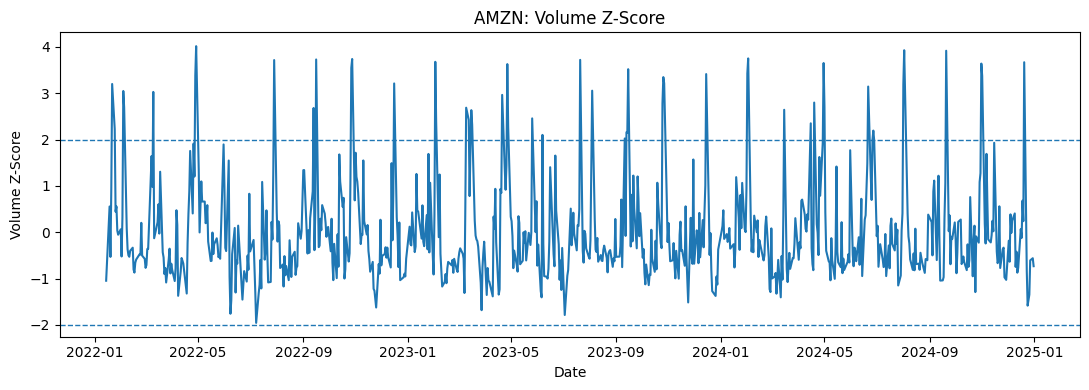

Saved figure: e:\Om\signalscope\reports\figures\AAPL_volume_zscore.png


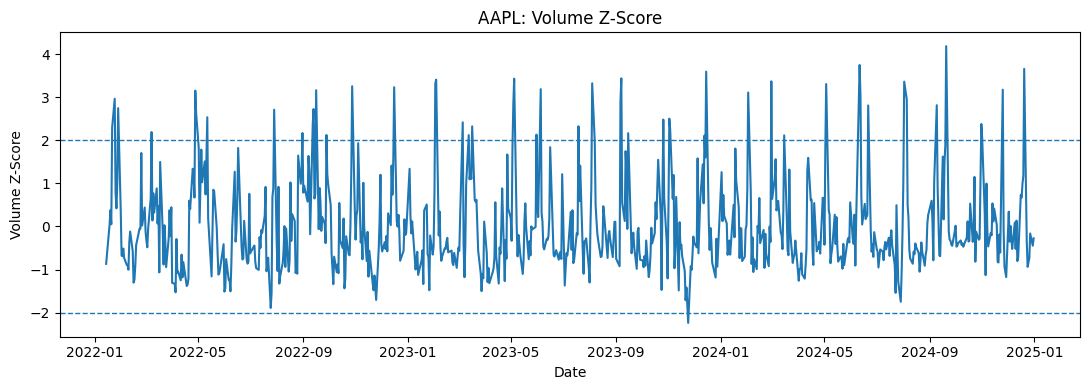

In [11]:
for ticker in TICKERS:
    part = master_df[master_df["ticker"] == ticker]
    if part.empty:
        continue
    plt.figure(figsize=(11, 4))
    plt.plot(part["date"], part["volume_zscore"])
    plt.axhline(2, linestyle="--", linewidth=1)
    plt.axhline(-2, linestyle="--", linewidth=1)
    plt.title(f"{ticker}: Volume Z-Score")
    plt.xlabel("Date")
    plt.ylabel("Volume Z-Score")
    save_current_figure(f"{ticker}_volume_zscore.png")
    plt.show()


## 9. EDA: Google Trends Signal


In [12]:
if trends_features_df is not None and not trends_features_df.empty:
    plt.figure(figsize=(11, 4))
    plt.plot(trends_features_df["date"], trends_features_df["ai_trend_score"])
    plt.title("Google Trends: AI Attention Score")
    plt.xlabel("Date")
    plt.ylabel("AI Trend Score")
    save_current_figure("google_trends_ai_attention_score.png")
    plt.show()

    trend_cols = [c for c in AI_TREND_KEYWORDS if c in trends_raw_df.columns]
    if trend_cols:
        plt.figure(figsize=(11, 5))
        for col in trend_cols:
            plt.plot(trends_raw_df["date"], trends_raw_df[col], label=col)
        plt.title("Google Trends Keywords")
        plt.xlabel("Date")
        plt.ylabel("Relative Search Interest")
        plt.legend()
        save_current_figure("google_trends_keywords.png")
        plt.show()
else:
    print("Skipping Google Trends plots because no Trends data is available.")


Skipping Google Trends plots because no Trends data is available.


## 10. EDA: SEC Filing Signal


,ticker,filed_date,period_of_report,word_count,sec_ai_total_count,sec_ai_density,sec_ai_density_yoy_change
0,AAPL,2022-10-28,2022-09-24,33786,3,0.000089,NaN
1,AAPL,2023-11-03,2023-09-30,31484,5,0.000159,0.000070
2,AAPL,2024-11-01,2024-09-28,31879,8,0.000251,0.000092
3,AMZN,2022-02-04,2021-12-31,39817,15,0.000377,NaN
4,AMZN,2023-02-03,2022-12-31,42155,16,0.000380,0.000003
5,AMZN,2024-02-02,2023-12-31,44436,23,0.000518,0.000138
6,GOOG,2022-02-02,2021-12-31,52868,12,0.000227,NaN
7,GOOG,2023-02-03,2022-12-31,51042,10,0.000196,-0.000031
8,GOOG,2024-01-31,2023-12-31,54159,14,0.000258,0.000063
9,META,2022-02-03,2021-12-31,67111,15,0.000224,NaN


Saved figure: e:\Om\signalscope\reports\figures\sec_latest_ai_density_by_company.png


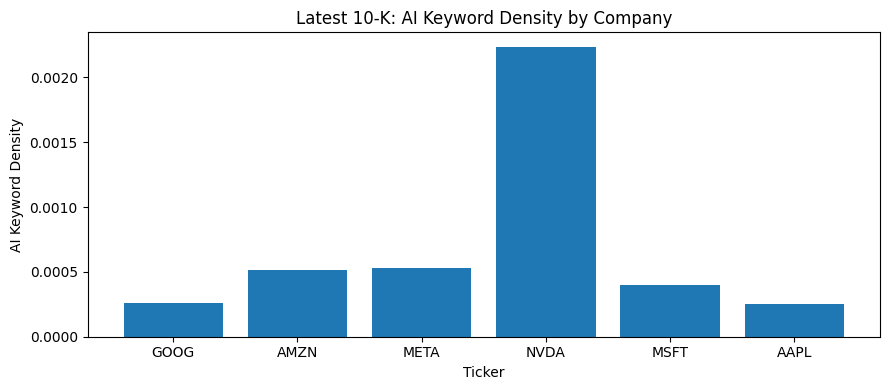

In [13]:
if sec_features_df is not None and not sec_features_df.empty:
    display_cols = ["ticker", "filed_date", "period_of_report", "word_count", "sec_ai_total_count", "sec_ai_density", "sec_ai_density_yoy_change"]
    display(sec_features_df[[c for c in display_cols if c in sec_features_df.columns]])

    plt.figure(figsize=(9, 4))
    latest_sec = sec_features_df.sort_values("filed_date").groupby("ticker").tail(1)
    plt.bar(latest_sec["ticker"], latest_sec["sec_ai_density"])
    plt.title("Latest 10-K: AI Keyword Density by Company")
    plt.xlabel("Ticker")
    plt.ylabel("AI Keyword Density")
    save_current_figure("sec_latest_ai_density_by_company.png")
    plt.show()
else:
    print("Skipping SEC plots because no SEC features are available.")


## 11. EDA: Forward Returns and Drawdown


Saved figure: e:\Om\signalscope\reports\figures\distribution_5d_forward_returns.png


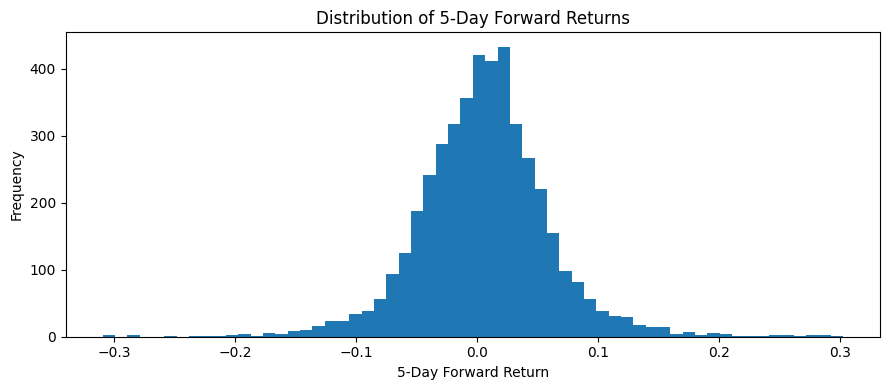

Saved figure: e:\Om\signalscope\reports\figures\distribution_5d_forward_drawdowns.png


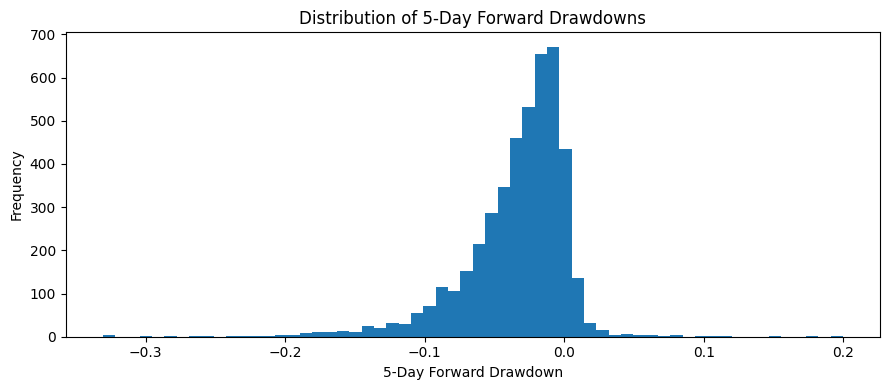

In [14]:
plt.figure(figsize=(9, 4))
plt.hist(master_df["return_5d_forward"].dropna(), bins=60)
plt.title("Distribution of 5-Day Forward Returns")
plt.xlabel("5-Day Forward Return")
plt.ylabel("Frequency")
save_current_figure("distribution_5d_forward_returns.png")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(master_df["drawdown_5d_forward"].dropna(), bins=60)
plt.title("Distribution of 5-Day Forward Drawdowns")
plt.xlabel("5-Day Forward Drawdown")
plt.ylabel("Frequency")
save_current_figure("distribution_5d_forward_drawdowns.png")
plt.show()


In [15]:
event_df = master_df.copy()
event_df["high_volume_event"] = event_df["volume_zscore"] >= 2

event_df.groupby("high_volume_event").agg(
    rows=("date", "count"),
    avg_5d_return=("return_5d_forward", "mean"),
    median_5d_return=("return_5d_forward", "median"),
    worst_5d_drawdown=("drawdown_5d_forward", "min"),
    avg_20d_volatility=("rolling_volatility_20d", "mean"),
).reset_index()


,high_volume_event,rows,avg_5d_return,median_5d_return,worst_5d_drawdown,avg_20d_volatility
0,False,4227,0.005426,0.005784,-0.326594,0.022806
1,True,291,0.004128,0.004748,-0.330805,0.021240


In [16]:
if "ai_trend_bucket" in master_df.columns and master_df["ai_trend_bucket"].notna().any():
    trend_bucket_summary = master_df.groupby("ai_trend_bucket").agg(
        rows=("date", "count"),
        avg_5d_return=("return_5d_forward", "mean"),
        median_5d_return=("return_5d_forward", "median"),
        worst_5d_drawdown=("drawdown_5d_forward", "min"),
        avg_volume_zscore=("volume_zscore", "mean"),
    ).reset_index()
    display(trend_bucket_summary)
else:
    print("No trend bucket available.")


,ai_trend_bucket,rows,avg_5d_return,median_5d_return,worst_5d_drawdown,avg_volume_zscore
0,missing,4518,0.005341,0.005754,-0.330805,0.000287


## 12. Correlation Analysis


Saved figure: e:\Om\signalscope\reports\figures\feature_correlation_matrix.png


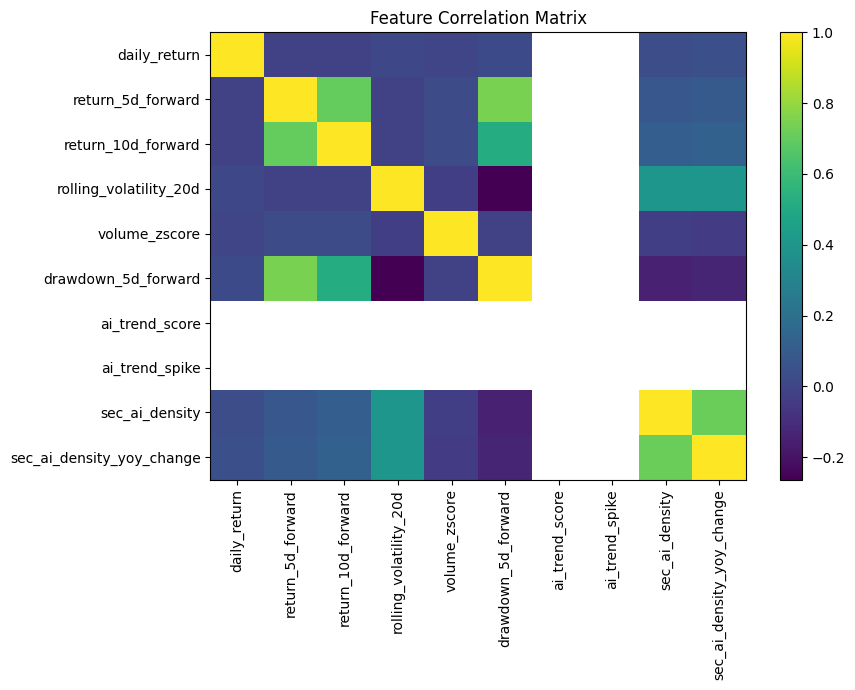

,daily_return,return_5d_forward,return_10d_forward,rolling_volatility_20d,volume_zscore,drawdown_5d_forward,ai_trend_score,ai_trend_spike,sec_ai_density,sec_ai_density_yoy_change
daily_return,1.000000,-0.019007,-0.014530,0.008444,0.001223,0.019881,NaN,NaN,0.037753,0.043324
return_5d_forward,-0.019007,1.000000,0.701639,-0.014903,0.028040,0.745869,NaN,NaN,0.080259,0.093667
return_10d_forward,-0.014530,0.701639,1.000000,-0.012883,0.030214,0.519091,NaN,NaN,0.113007,0.126703
rolling_volatility_20d,0.008444,-0.014903,-0.012883,1.000000,-0.026834,-0.263125,NaN,NaN,0.398859,0.400279
volume_zscore,0.001223,0.028040,0.030214,-0.026834,1.000000,-0.015792,NaN,NaN,-0.026490,-0.036818
drawdown_5d_forward,0.019881,0.745869,0.519091,-0.263125,-0.015792,1.000000,NaN,NaN,-0.148347,-0.134684
ai_trend_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ai_trend_spike,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sec_ai_density,0.037753,0.080259,0.113007,0.398859,-0.026490,-0.148347,NaN,NaN,1.000000,0.718475
sec_ai_density_yoy_change,0.043324,0.093667,0.126703,0.400279,-0.036818,-0.134684,NaN,NaN,0.718475,1.000000


In [17]:
corr_cols = [
    "daily_return", "return_5d_forward", "return_10d_forward", "rolling_volatility_20d",
    "volume_zscore", "drawdown_5d_forward", "ai_trend_score", "ai_trend_spike",
    "sec_ai_density", "sec_ai_density_yoy_change",
]
corr_cols = [c for c in corr_cols if c in master_df.columns]
corr = master_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Feature Correlation Matrix")
save_current_figure("feature_correlation_matrix.png")
plt.show()

corr


## 13. RL-Ready State Buckets

This converts continuous features into discrete low / medium / high buckets for tabular Q-learning.


In [18]:
def bucket_series_qcut(s: pd.Series, labels=("low", "medium", "high")) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() < 3 or s.nunique(dropna=True) < 3:
        return pd.Series(["missing"] * len(s), index=s.index)
    try:
        return pd.qcut(s, q=3, labels=labels, duplicates="drop").astype(str)
    except Exception:
        try:
            return pd.cut(s, bins=3, labels=labels, include_lowest=True).astype(str)
        except Exception:
            return pd.Series(["missing"] * len(s), index=s.index)


rl_df = master_df.copy()
rl_df["volume_bucket"] = rl_df.groupby("ticker")["volume_zscore"].transform(bucket_series_qcut)
rl_df["volatility_bucket"] = rl_df.groupby("ticker")["rolling_volatility_20d"].transform(bucket_series_qcut)
rl_df["recent_return_bucket"] = rl_df.groupby("ticker")["daily_return"].transform(bucket_series_qcut)
rl_df["trend_bucket"] = bucket_series_qcut(rl_df["ai_trend_score"]) if "ai_trend_score" in rl_df.columns else "missing"
rl_df["sec_ai_bucket"] = rl_df.groupby("ticker")["sec_ai_density"].transform(bucket_series_qcut) if "sec_ai_density" in rl_df.columns else "missing"

rl_df["state"] = (
    "trend=" + rl_df["trend_bucket"].astype(str)
    + "|volume=" + rl_df["volume_bucket"].astype(str)
    + "|volatility=" + rl_df["volatility_bucket"].astype(str)
    + "|recent_return=" + rl_df["recent_return_bucket"].astype(str)
    + "|sec_ai=" + rl_df["sec_ai_bucket"].astype(str)
)

rl_keep_cols = [
    "date", "ticker", "close", "volume", "daily_return", "return_5d_forward", "return_10d_forward",
    "drawdown_5d_forward", "volume_zscore", "rolling_volatility_20d", "ai_trend_score",
    "sec_ai_density", "trend_bucket", "volume_bucket", "volatility_bucket", "recent_return_bucket",
    "sec_ai_bucket", "state"
]
rl_keep_cols = [c for c in rl_keep_cols if c in rl_df.columns]
rl_ready_df = rl_df[rl_keep_cols].copy()

save_csv(rl_ready_df, PROCESSED_DIR / "rl_ready_dataset.csv")
print("RL-ready dataset shape:", rl_ready_df.shape)
rl_ready_df.head()


RL-ready dataset shape: (4518, 18)


,date,ticker,close,volume,daily_return,return_5d_forward,return_10d_forward,drawdown_5d_forward,volume_zscore,rolling_volatility_20d,ai_trend_score,sec_ai_density,trend_bucket,volume_bucket,volatility_bucket,recent_return_bucket,sec_ai_bucket,state
0,2022-01-03,AAPL,182.009995,104487900,NaN,-0.053953,-0.067084,-0.076040,NaN,NaN,NaN,NaN,missing,nan,nan,nan,nan,trend=missing|volume=nan|volatility=nan|recent...
1,2022-01-04,AAPL,179.699997,99310400,-0.012692,-0.025709,-0.074958,-0.064162,NaN,NaN,NaN,NaN,missing,nan,nan,low,nan,trend=missing|volume=nan|volatility=nan|recent...
2,2022-01-05,AAPL,174.919998,94537600,-0.026600,0.003487,-0.059513,-0.038589,NaN,NaN,NaN,NaN,missing,nan,nan,low,nan,trend=missing|volume=nan|volatility=nan|recent...
3,2022-01-06,AAPL,172.000000,96904000,-0.016693,0.001105,-0.055756,-0.022267,NaN,NaN,NaN,NaN,missing,nan,nan,low,nan,trend=missing|volume=nan|volatility=nan|recent...
4,2022-01-07,AAPL,172.169998,86709100,0.000988,0.005227,-0.061277,-0.023233,NaN,NaN,NaN,NaN,missing,nan,nan,medium,nan,trend=missing|volume=nan|volatility=nan|recent...


## 14. Final Outputs

The notebook creates:

```text
data/processed/market_features.csv
data/processed/google_trends_features.csv
data/processed/sec_filing_features.csv
data/processed/signalscope_master_dataset.csv
data/processed/rl_ready_dataset.csv
reports/figures/*.png
```

Use `rl_ready_dataset.csv` for the first Q-learning implementation.


In [19]:
print("Saved processed files:")
for path in sorted(PROCESSED_DIR.glob("*.csv")):
    print("-", path)

print("\nSaved figures:")
for path in sorted(FIGURES_DIR.glob("*.png"))[:20]:
    print("-", path)


Saved processed files:
- e:\Om\signalscope\data\processed\google_trends_features.csv
- e:\Om\signalscope\data\processed\market_features.csv
- e:\Om\signalscope\data\processed\rl_ready_dataset.csv
- e:\Om\signalscope\data\processed\sec_filing_features.csv
- e:\Om\signalscope\data\processed\signalscope_eda_dataset.csv
- e:\Om\signalscope\data\processed\signalscope_master_dataset.csv

Saved figures:
- e:\Om\signalscope\reports\figures\AAPL_close_price.png
- e:\Om\signalscope\reports\figures\AAPL_volume_zscore.png
- e:\Om\signalscope\reports\figures\AMZN_close_price.png
- e:\Om\signalscope\reports\figures\AMZN_volume_zscore.png
- e:\Om\signalscope\reports\figures\distribution_5d_forward_drawdowns.png
- e:\Om\signalscope\reports\figures\distribution_5d_forward_returns.png
- e:\Om\signalscope\reports\figures\feature_correlation_matrix.png
- e:\Om\signalscope\reports\figures\GOOG_close_price.png
- e:\Om\signalscope\reports\figures\GOOG_volume_zscore.png
- e:\Om\signalscope\reports\figures\MET